## Alon, Matias, Szegedy (AMS)

In [ ]:
import numpy as np
from utils import hash_func
def AMS(stream, r):
    '''
    Description:
        Uses Alon, Matias, Szegedy (AMS) algorithm to approximate 2 norm
    Inputs:
        stream: stream vector of random values
        r: number of algorithm iterations
    Outputs:
        est_norm: estimated 2 norm
        random_signs: random_signs for the last iteration 
    '''
    
    norms = np.zeros(r)
    for s_i in stream:
        for i in range(r):
            v_i = 2*hash_func(i, s_i, 2) - 1 # randomize v_i for each iteration of the algorithm
            norms[i] += v_i
    return np.sqrt(np.median(norms**2))

### Uniform Stream Test

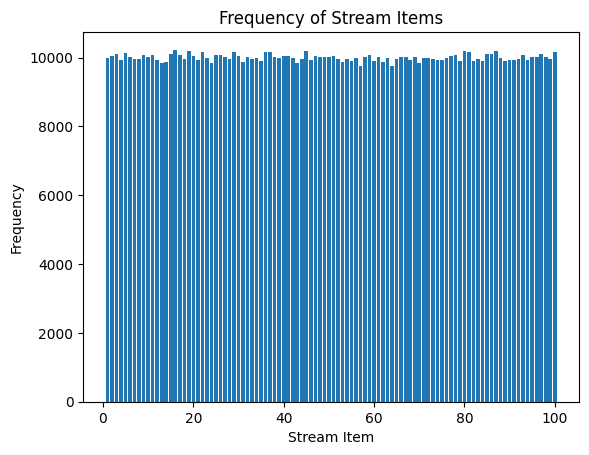

AMS Value: 79990.0
Ground Truth: 100004.46851016209


In [3]:
from utils import generate_stream_uniform, plot_stream

unif_strm, unif_freq = generate_stream_uniform(n=100, m=int(1e6))
plot_stream(unif_strm)

print("AMS Estimate:", AMS(unif_strm, 5))
print("Ground Truth:", np.linalg.norm(unif_freq, 2))

### Skewed Stream Test

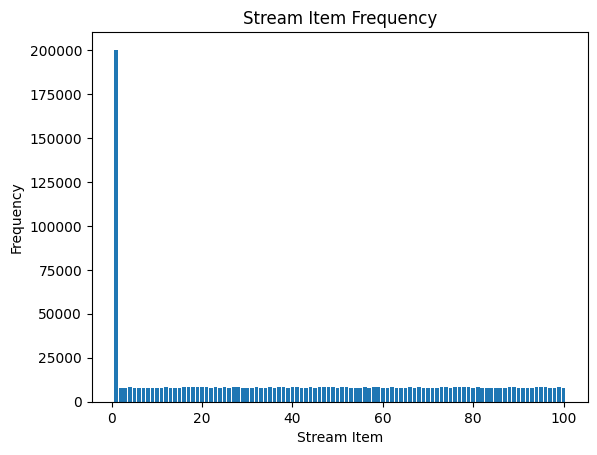

AMS Value: 191556.0
Ground Truth: 215688.21204229034


In [4]:
from utils import generate_stream_skewed, plot_stream

skwd_strm, skwd_freq = generate_stream_skewed(n=100, m=int(1e6), q=1, k=2)
plot_stream(skwd_strm)

print("AMS Estimate:", AMS(skwd_strm, 5))
print("Ground Truth:", np.linalg.norm(skwd_freq, 2))

## Alon, Matias, Szegedy Augmented (AMSA)

In [7]:
import numpy as np
from utils import hash_func

def AMSA(stream, heavy, r):
    '''
    Description:
        Uses AMS algorithm + heavy hitter knowledge to approximate 2 norm
    Inputs:
        stream: stream vector of random values
        r: number of algorithm iterations
        heavy: list of heavy hitters
    Outputs:
        Estimated 2 norm of frequency vector
    '''
    l = len(heavy)
    buckets = np.zeros(l+r)
    # process the heavy hitters and non-heavy hitters
    for s_i in stream:
        try:
            index = heavy.index(s_i)
            buckets[index] += 1
        except ValueError:
            # s_i is not a heavy hitter
            for i in range(r):
                v_i = 2*hash_func(i, s_i, 2) - 1
                buckets[l+i] += v_i
    # approximate all non-heavy hitters
    buckets[l] = np.sqrt(np.median(buckets[l:]**2))
    return np.linalg.norm(buckets[:l+1], 2)

### Uniform Stream Test

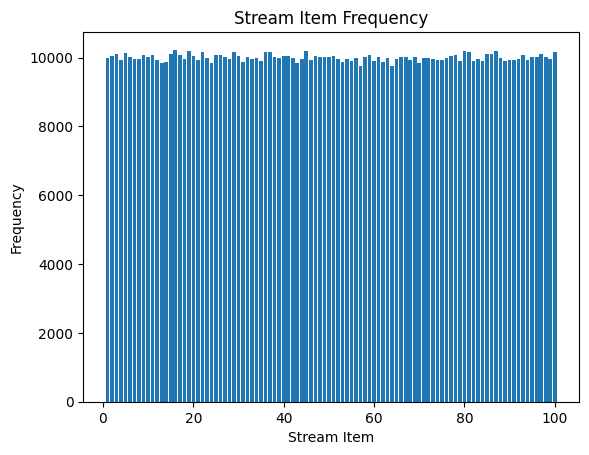

AMSA Estimate: 79990.0
Ground Truth: 100004.46851016209


In [8]:
from utils import generate_stream_uniform, plot_stream

unif_strm, unif_freq = generate_stream_uniform(n=100, m=int(1e6))
plot_stream(unif_strm)

print("AMSA Estimate:", AMSA(unif_strm,[], 5))
print("Ground Truth:", np.linalg.norm(unif_freq, 2))

### Skewed Stream Test

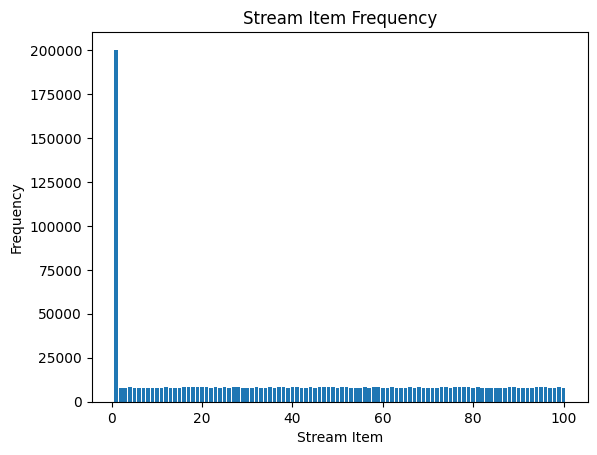

AMSA Estimate: 207835.37094537108
Ground Truth: 215688.21204229034


In [9]:
from utils import generate_stream_skewed, plot_stream

skwd_strm, skwd_freq = generate_stream_skewed(n=100, m=int(1e6), q=1, k=2)
plot_stream(skwd_strm)

print("AMSA Estimate:", AMSA(skwd_strm,[1], 5))
print("Ground Truth:", np.linalg.norm(skwd_freq, 2))